# Pokebot — Gen 1 Random Battle

Bot Pokémon **Gen 1** entraîné par **Reinforcement Learning** (PPO) via `poke-env` et `Stable-Baselines3`.  
Format : `gen1randombattle` sur Pokémon Showdown.

---

## Pipeline d'entraînement (Curriculum Learning)

| Phase | Adversaire | Steps | Objectif |
|---|---|---|---|
| **0** | Imitation (replays ELO ≥ 1200) | ~50 k  | Donner une base stratégique par imitation |
| **1** | Random | 20 k | Echauffement rapide, pour consolider l'imitation |
| **2** | MaxBasePower | 200 k | Apprendre les type de matchups, et savoir quand switcher (et si y'a besoin de ...) |
| **3** | Self-Play | 1 M | S'améliorer contre soi-même |

---

## Espace d'observation — 58 features

```
10  Pokémon actif     : HP fraction, 7 boosts, statut, type matchup adversaire, move lock-in
 5  Adversaire actif  : HP fraction, statut, type matchup, boosts cumulés (Atk ou SAtk boosts important pour anticiper KOs)
16  4 moves × 4       : base_power, accuracy, type_effectiveness, priority
 8  Équipe            : 6 HP fractions + compteur KO alliés/adversaires
 3  Météo             : Rain, Sun, Sandstorm (one-hot)
 1  Tour courant      : normalisé (juste le numero du tour)
15  5 bench × 3       : HP, matchup défensif, meilleur potentiel offensif
```

---

## Prérequis

1. **Serveur Showdown local** : `node pokemon-showdown start --no-security` (depuis le dossier `pokemon-showdown/`)
2. **Exécuter les cellules dans l'ordre** (0 → Évaluation → Démo)
3. MLflow optionnel : `mlflow ui` pour suivre les runs

In [ ]:
# Librairies

from poke_env.battle.abstract_battle import AbstractBattle
from poke_env.battle import Weather, Status, PokemonType
from poke_env.battle.move import Move
from poke_env.battle.pokemon import Pokemon
from poke_env.environment.singles_env import SinglesEnv
from poke_env.player.battle_order import DefaultBattleOrder
from gymnasium.spaces import Box
import numpy as np

import os
from pathlib import Path

## PokemonEnv — Perception et recompense du bot

Cette cellule est le coeur de l'environnement d'apprentissage. Elle definit les deux fonctions que MaskablePPO interroge en permanence pendant l'entrainement.

### `embed_battle()` — Ce que le bot voit

Convertit l'etat complet du combat en un vecteur de **58 nombres** (l'observation). A chaque tour, avant de choisir une action, le reseau de neurones recoit ce vecteur en entree. Si une information n'est pas dans ce vecteur, le bot ne peut pas s'en servir pour decider.

```
Pokemon actif (HP, 7 boosts, statut, matchup)     →  10 valeurs
Adversaire actif (HP, 3 boosts, statut)            →   5 valeurs
4 moves (base_power, accuracy, STAB, type_eff)     →  16 valeurs
Equipe (6 HP + compteurs KO allies/adverses)       →   8 valeurs
Meteo (Pluie / Soleil / Sable) + tour courant      →   4 valeurs
5 Pokemon du banc (HP, def matchup, off potentiel) →  15 valeurs
                                              TOTAL = 58 valeurs
```

### `calc_reward()` — Ce que le bot optimise

Calcule le signal de recompense apres chaque action. Il y a deux composantes :

- **Base** (fournie par poke-env) : +/− proportionnel aux KO infliges/subis, aux HP perdus/gagnes, aux statuts, et +30/−30 pour la victoire/defaite.
- **Shaping** (ce qu'on a configure) : bonus/malus supplementaires pour orienter vers de bonnes habitudes — rester dans un bon matchup, switcher quand c'est necessaire, utiliser le bon move au bon moment, ne pas spammer les moves de statut inutilement.

C'est le reward shaping qui distingue un bot qui "survit" d'un bot qui "joue strategiquement".

In [ ]:
# Racine du projet
PROJECT_ROOT = Path(os.getcwd()) if (Path(os.getcwd()) / "pokemon-showdown").exists() else Path(os.getcwd()).parent
MODEL_DIR = PROJECT_ROOT / "models"

# Moves lock-in Gen 1 (Thrash, Petal Dance - Outrage n'existe pas en Gen 1)
LOCK_IN_MOVES = {"thrash", "petaldance"}

# 10 (actif) + 5 (adversaire) + 16 (4 moves x 4) + 8 (6 HP equipe + fainted counts)
# + 3 (weather) + 1 (turn) + 15 (5 bench x 3: HP, def matchup, best offensive move)
NUM_FEATURES = 58


# Mappng des differents statuts (pour le calcul du reward)
STATUS_MAP = {
    Status.BRN: 1, Status.FRZ: 2, Status.PAR: 3,
    Status.PSN: 4, Status.SLP: 5, Status.TOX: 6,
}

# Definition de l'environnement (point de depart pour l'entrainement)
class PokemonEnv(SinglesEnv):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.observation_spaces = {
            agent: Box(low=-1, high=4, shape=(NUM_FEATURES,), dtype=np.float32)
            for agent in self.possible_agents
        }
        self._last_order = None

    def step(self, actions):
        """Stocke l'ordre (move/switch) de notre agent avant le step pour calc_reward."""
        self._last_order = None
        if self.agents and self.battle1 and not self.battle1.finished:
            try:
                act = actions.get(self.agents[0])
                if act is not None:
                    self._last_order = self.action_to_order(
                        act, self.battle1, fake=self.fake, strict=self.strict
                    )
            except Exception:
                pass
        return super().step(actions)

    @staticmethod
    def action_to_order(action, battle, fake=False, strict=False):
        """Override: quand seul ordre valide = default (Struggle/Recharge), retourne DefaultBattleOrder."""
        valid_strs = [str(o) for o in battle.valid_orders]
        if len(valid_strs) == 1 and valid_strs[0] == "/choose default":
            return DefaultBattleOrder()
        return SinglesEnv.action_to_order(action, battle, fake, strict)

    def _encode_status(self, status) -> float:
        if status is None:
            return 0.0
        return STATUS_MAP.get(status, 0) / 6.0

    def _type_multiplier(self, move_or_mon, target_pokemon) -> float:
        try:
            return target_pokemon.damage_multiplier(move_or_mon) / 4.0
        except Exception:
            return 0.25

    def _defensive_matchup(self, pokemon, opponent) -> float:
        """Combien de degats les types de l'adversaire infligent a notre pokemon (moins = mieux)."""
        try:
            mult = 1.0
            if opponent.type_1:
                mult *= pokemon.damage_multiplier(opponent.type_1)
            if opponent.type_2:
                mult *= pokemon.damage_multiplier(opponent.type_2)
            return mult / 4.0
        except Exception:
            return 0.25

    def _best_offensive_potential(self, pokemon, opponent) -> float:
        """potentiel offensif du type de pokemon par rapport a l'adversaire."""
        try:
            if not pokemon.moves:
                return 0.0
            best = max(
                opponent.damage_multiplier(move) for move in pokemon.moves.values()
            )
            return best / 4.0
        except Exception:
            return 0.25

    def embed_battle(self, battle: AbstractBattle) -> np.ndarray:
        """ Convertir l'etat du combat en vecteur numpy de 58 features (l'observation que reçoit le PPO) """
        obs = np.zeros(NUM_FEATURES, dtype=np.float32)
        idx = 0

        active = battle.active_pokemon
        opponent = battle.opponent_active_pokemon

        # === Notre pokemon actif (10) ===
        if active:
            obs[idx] = active.current_hp_fraction
            idx += 1
            boosts = active.boosts
            for stat in ["atk", "def", "spa", "spd", "spe", "accuracy", "evasion"]:
                obs[idx] = boosts.get(stat, 0) / 6.0
                idx += 1
            obs[idx] = self._encode_status(active.status)
            idx += 1
            if opponent:
                obs[idx] = self._type_multiplier(active, opponent)
            idx += 1
        else:
            idx += 10

        # === Pokemon adversaire actif (5) ===
        if opponent:
            obs[idx] = opponent.current_hp_fraction
            idx += 1
            opp_boosts = opponent.boosts
            for stat in ["atk", "def", "spe"]:
                obs[idx] = opp_boosts.get(stat, 0) / 6.0
                idx += 1
            obs[idx] = self._encode_status(opponent.status)
            idx += 1
        else:
            idx += 5

        # === Nos 4 moves (4 x 4 = 16) ===
        for i in range(4):
            if i < len(battle.available_moves):
                move = battle.available_moves[i]
                try:
                    p = self._safe_move_props(move)
                    obs[idx] = p["base_power"] / 150.0
                    obs[idx + 1] = p["accuracy"]
                    stab = 1.0 if active and move.type in active.types else 0.0
                    obs[idx + 2] = stab
                    if opponent:
                        obs[idx + 3] = self._type_multiplier(move, opponent)
                    else:
                        obs[idx + 3] = 0.25
                except (KeyError, TypeError, AttributeError):
                    obs[idx] = 0.0
                    obs[idx + 1] = 1.0
                    obs[idx + 2] = 0.0
                    obs[idx + 3] = 0.25
            idx += 4

        # === Etat de l'equipe (11) ===
        team_mons = list(battle.team.values())
        for i in range(6):
            if i < len(team_mons):
                obs[idx] = team_mons[i].current_hp_fraction
            idx += 1

        opp_fainted = sum(1 for m in battle.opponent_team.values() if m.fainted)
        our_fainted = sum(1 for m in battle.team.values() if m.fainted)
        obs[idx] = opp_fainted / 6.0
        idx += 1
        obs[idx] = our_fainted / 6.0
        idx += 1

        # Turn (0-1, plafonne a 30 pour early game)
        obs[idx] = min(getattr(battle, "turn", 0), 30) / 30.0
        idx += 1

        weather = battle.weather
        if weather:
            w = list(weather.keys())[0] if weather else None
            obs[idx] = 1.0 if w == Weather.RAINDANCE else 0.0
            obs[idx + 1] = 1.0 if w == Weather.SUNNYDAY else 0.0
            obs[idx + 2] = 1.0 if w == Weather.SANDSTORM else 0.0
        idx += 3

        # === Switches disponibles (5 x 3 = 15) ===
        # Pour chaque pokemon du banc: HP + matchup defensif + meilleur move offensif
        bench = [m for m in battle.team.values() if m != active and not m.fainted]
        for i in range(5):
            if i < len(bench):
                obs[idx] = bench[i].current_hp_fraction
                if opponent:
                    obs[idx + 1] = self._defensive_matchup(bench[i], opponent)
                    obs[idx + 2] = self._best_offensive_potential(bench[i], opponent)
                else:
                    obs[idx + 1] = 0.25
                    obs[idx + 2] = 0.25
            idx += 3

        return obs

    # dps attendus du meilleur move (base_power * type_eff * stab) === IMPORTANT !!! ===
    def _best_damaging_move_potential(self, battle, active, opponent) -> float:
        """Score de degats attendus du meilleur move (base_power * type_eff * stab)."""
        if not opponent or not battle.available_moves:
            return 0.0
        best = 0.0
        for move in battle.available_moves:
            try:
                p = self._safe_move_props(move)
                te = opponent.damage_multiplier(move) / 4.0
                stab = 1.5 if active and move.type in active.types else 1.0
                dmg_proxy = (p["base_power"] / 150.0) * te * stab
                best = max(best, dmg_proxy)
            except (KeyError, TypeError, AttributeError, ValueError):
                pass
        return best

    def _has_status_only_moves(self, battle) -> bool:
        """True si nos moves disponibles sont only status (risque de spam status inutiles)."""
        if not battle.available_moves:
            return True
        try:
            max_bp = max(self._safe_move_props(m)["base_power"] for m in battle.available_moves)
            return max_bp < 40
        except (KeyError, TypeError, AttributeError):
            return True

    def _get_last_move(self):
        """Retourne le Move choisi au dernier step, ou None."""
        order = getattr(self, "_last_order", None)
        if order is not None and isinstance(getattr(order, "order", None), Move):
            return order.order
        return None

    def _get_last_was_switch(self):
        """True si on a switch au dernier step."""
        order = getattr(self, "_last_order", None)
        return order is not None and isinstance(getattr(order, "order", None), Pokemon)

    def _safe_move_props(self, move):
        """Acces securise aux props Move (calcul complet d la puissance du moves apres les eventuels altérations de stats +-)."""
        try:
            e = move.entry
            heal = 0.0
            if e.get("heal") and isinstance(e["heal"], (list, tuple)) and len(e["heal"]) >= 2:
                heal = e["heal"][0] / e["heal"][1]
            acc = e.get("accuracy")
            acc_val = 1.0 if acc is True else (acc / 100.0 if isinstance(acc, (int, float)) else 1.0)
            sb = e.get("selfBoost") or e.get("self") or {}
            boosts = sb.get("boosts") if isinstance(sb, dict) else None
            return {
                "self_boost": boosts,
                "heal": heal,
                "priority": e.get("priority", 0),
                "accuracy": acc_val,
                "base_power": e.get("basePower", 0),
                "self_destruct": e.get("selfdestruct"),
            }
        except Exception:
            return {"self_boost": None, "heal": 0.0, "priority": 0, "accuracy": 1.0, "base_power": 0, "self_destruct": None}


    # Calcul de la recompense ===> c'est la que beaucoup de décisions sont importantes pour la suite du projet
    def calc_reward(self, battle: AbstractBattle) -> float:
        base = self.reward_computing_helper(
            battle,
            fainted_value=3.0,
            hp_value=1.5,
            status_value=0.5,
            victory_value=30.0,
        )

        bonus = 0.0
        active = battle.active_pokemon
        opponent = battle.opponent_active_pokemon
        def_score = 0.5
        can_likely_ko = False
        opp_has_status = opponent.status is not None if opponent else False
        bench = [m for m in battle.team.values() if m != active and not m.fainted] if active else []

        # HP efficiency
        our_hp = sum(m.current_hp_fraction for m in battle.team.values() if not m.fainted)
        opp_hp = sum(m.current_hp_fraction for m in battle.opponent_team.values() if not m.fainted)
        hp_diff = (our_hp - opp_hp) / 6.0
        bonus += hp_diff * 0.5

        our_fainted = sum(1 for m in battle.team.values() if m.fainted)
        opp_fainted = sum(1 for m in battle.opponent_team.values() if m.fainted)
        bonus += (opp_fainted - our_fainted) * 0.3

        if active and opponent and not active.fainted:
            def_score = self._defensive_matchup(active, opponent)
            off_score = self._best_offensive_potential(active, opponent)

            # Matchup combo: good D & good O
            resistance_bonus = max(0, 0.25 - def_score) * 2.0
            offense_bonus = max(0, off_score - 0.25) * 2.0
            bonus += (resistance_bonus + offense_bonus) * 0.3

            # Degats attendus: recompense avoir un move opti sur l'adversaire
            dmg_potential = self._best_damaging_move_potential(battle, active, opponent)
            bonus += dmg_potential * 0.4

            # Anti-spam status: penalise si adversaire a deja un status et on n'a que des moves faibles (OSKOUR la boucle Berceuse)
            opp_has_status = opponent.status is not None
            if opp_has_status and self._has_status_only_moves(battle):
                bonus -= 0.5

            # Switch defensif: penalise rester si on prend du damage super efficace et qu'on a mieux sur le banc
            # SAUF si on peut tuer (degats eleves + adversaire bas) -> rester pour finir
            bench = [m for m in battle.team.values() if m != active and not m.fainted]
            can_likely_ko = dmg_potential > 0.6 and opponent.current_hp_fraction < 0.6
            if def_score > 0.5 and not can_likely_ko:
                best_bench_def = min(
                    self._defensive_matchup(m, opponent) for m in bench
                ) if bench else 1.0
                if best_bench_def < def_score - 0.15:
                    bonus -= 0.6  # wip 

            # Bonus si on a un meilleur switch dispo (si un monstre fight mieux le poke en face)
            if bench:
                our_combo = (1.0 - def_score) + off_score
                best_bench_combo = max(
                    (1.0 - self._defensive_matchup(m, opponent))
                    + self._best_offensive_potential(m, opponent)
                    for m in bench
                )
                if best_bench_combo > our_combo + 0.2:
                    bonus += 0.5  

        # === Rewards pour SWITCH (uniquement si gain reel: def, def+atk, ou atk si actif faible) ===
        if self._get_last_was_switch() and active and opponent:
            def_score = self._defensive_matchup(active, opponent)
            off_score = self._best_offensive_potential(active, opponent)
            bench = [m for m in battle.team.values() if m != active and not m.fainted]

            # Switch defensif: on a switche vers un poke qui resiste bien
            if def_score < 0.5:
                bonus += 0.55 # wip

            # Switch defensif + combo attaque efficace: resiste ET a du SE dans son set
            if def_score < 0.5 and off_score > 0.5:
                bonus += 0.5 # wip

            # Switch vers meilleur combo (strictement meilleur, pas de switch pour rien)
            if bench:
                our_combo = (1.0 - def_score) + off_score
                best_bench = max(
                    (1.0 - self._defensive_matchup(m, opponent))
                    + self._best_offensive_potential(m, opponent)
                    for m in bench
                )
                if our_combo > best_bench + 0.1:
                    bonus += 0.3  # wip (bonus en plus de la diff de combo)

        # === Rewards bases sur l'action choisie (move/switch) ===
        last_move = self._get_last_move()
        if last_move is not None and active and opponent:
            try:
                p = self._safe_move_props(last_move)
                # 1. Setup moves: bonus si on a utilise un boost et qu'on est en bonne position
                if p["self_boost"] and def_score < 0.5 and active.current_hp_fraction > 0.4:
                    bonus += 0.4
                # 2. Recovery: bonus si on a heal et qu'on en avait besoin
                if p["heal"] > 0:
                    if active.current_hp_fraction < 0.95 and def_score < 0.6:
                        bonus += 0.35
                    elif active.current_hp_fraction > 0.9 and def_score < 0.5:
                        bonus -= 0.2  # heal inutile alors qu'on etait safe
                # 3. Priority: bonus si move prioritaire pour finir un adversaire bas
                if p["priority"] > 0 and opponent.current_hp_fraction < 0.35:
                    bonus += 0.3
                # 4. Accuracy: penalise move imprecis quand on avait mieux (le haxx est reel)
                if (p["accuracy"] < 0.8 and active.moves and last_move.id in active.moves):
                    mvs = list(active.moves.values())
                    best_acc = 0.0
                    for m in mvs:
                        try:
                            a = self._safe_move_props(m)["accuracy"]
                            best_acc = max(best_acc, a)
                        except Exception:
                            pass
                    if best_acc > p["accuracy"] + 0.15:
                        bonus -= 0.2
                # 5. Capitalisation status: bonus attaquer un adv paralyse/endormi/gelé
                if opp_has_status and p["base_power"] > 0:
                    bonus += 0.25
                # 6. Explosion/Self-Destruct: par pitié non !
                if p["self_destruct"] and bench:
                    bonus -= 0.35
                # 7. Lock-in (Thrash, Petal Dance): penalise si adv resiste
                if last_move.id in LOCK_IN_MOVES:
                    try:
                        mult = opponent.damage_multiplier(last_move)
                        if mult < 1.0:
                            bonus -= 0.4
                    except Exception:
                        pass
            except (TypeError, AttributeError, ValueError, KeyError):
                pass  # donnees move Gen1 parfois incompletes

        # 8. Momentum: bonus pour avantage au score
        if our_fainted < opp_fainted and our_fainted < 3:
            bonus += 0.2
        # 9. Vitesse: bonus si on a des boosts spe et qu'on peut KO
        if active and opponent and can_likely_ko:
            spe_boost = active.boosts.get("spe", 0)
            if spe_boost > 0 or (opponent.status and opponent.status in (Status.PAR, Status.SLP, Status.FRZ)):
                bonus += 0.2
        # 10. Boosts adverses: renforce switch defensif si adv a un setup de boost 
        if active and opponent:
            opp_atk = opponent.boosts.get("atk", 0)
            if opp_atk >= 2 and def_score > 0.5 and bench:
                best_bench_def = min(self._defensive_matchup(m, opponent) for m in bench)
                if best_bench_def < def_score:
                    bonus -= 0.4

        return base + bonus

## Environnement d'apprentissage — `PokemonEnv` + `GymWrapper`

### `PokemonEnv` (cellule précédente)
Hérite de `SinglesEnv` (poke_env). Définit deux méthodes clés :
- **`embed_battle(battle)`** : convertit l'état du combat en vecteur numpy de **58 features** (l'observation que reçoit le PPO)
- **`calc_reward(battle)`** : calcule le signal de récompense à chaque tour

### `GymWrapper`
Adapte l'interface **PettingZoo** (multi-agent) de `poke_env` vers l'interface **Gymnasium** (single-agent) attendue par Stable-Baselines3.

```
poke_env (PettingZoo)  →  GymWrapper  →  SB3 MaskablePPO
    Agent1 = RL bot           │
    Agent2 = Adversaire  ←────┘  (stratégie configurable)
```

### Stratégies adversaire disponibles
| Stratégie | Comportement |
|---|---|
| `"random"` | Move aléatoire parmi les moves valides |
| `"max_power"` | Toujours le move avec la plus grande base power |
| `"self_play"` | Charge une copie du modèle RL en cours d'entraînement |

### Action Masking
`MaskablePPO` masque les actions invalides (moves sans PP, switch impossible, etc.) pour ne jamais générer d'action illégale → accélère considérablement l'apprentissage.

In [2]:
import gymnasium as gym
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from poke_env.environment.singles_env import SinglesEnv


class GymWrapper(gym.Env):
    """Wraps PettingZoo PokemonEnv -> Gymnasium env for SB3.
    Agent1 = RL agent, Agent2 = configurable opponent strategy."""

    OPPONENT_RANDOM = "random"
    OPPONENT_MAX_POWER = "max_power"
    OPPONENT_SELF_PLAY = "self_play"

    def __init__(self, poke_env, opponent_strategy="max_power", self_play_model=None):
        super().__init__()
        self.poke_env = poke_env
        self.agent_id = poke_env.possible_agents[0]
        self.opp_id = poke_env.possible_agents[1]
        self.observation_space = poke_env.observation_spaces[self.agent_id]
        self.action_space = poke_env.action_spaces[self.agent_id]
        self.opponent_strategy = opponent_strategy
        self.self_play_model = self_play_model

    def _build_action_mask(self, battle) -> np.ndarray:
        """Build a boolean mask of valid actions from the battle state."""
        mask = np.zeros(self.action_space.n, dtype=bool)
        if battle is None or battle.finished:
            mask[0] = True
            return mask
        for order in battle.valid_orders:
            try:
                action = SinglesEnv.order_to_action(order, battle, fake=True, strict=False)
                action_int = int(action)
                if 0 <= action_int < self.action_space.n:
                    mask[action_int] = True
                elif action_int == -2:
                    # DefaultBattleOrder (Struggle/Recharge): map to action 0
                    mask[0] = True
            except Exception:
                continue
        if not mask.any():
            mask[0] = True
        return mask

    def action_masks(self) -> np.ndarray:
        battle = self.poke_env.battle1
        return self._build_action_mask(battle)

    def _opponent_action(self) -> np.int64:
        battle = self.poke_env.battle2
        if self.opponent_strategy == self.OPPONENT_RANDOM:
            mask = self._build_action_mask(battle)
            valid_indices = np.where(mask)[0]
            return np.int64(np.random.choice(valid_indices))

        elif self.opponent_strategy == self.OPPONENT_SELF_PLAY and self.self_play_model:
            obs = self.poke_env.embed_battle(battle)
            mask = self._build_action_mask(battle)
            action, _ = self.self_play_model.predict(obs, action_masks=mask)
            return np.int64(action)

        else:  # max_power
            if battle and battle.available_moves:
                try:
                    best = max(
                        range(len(battle.available_moves)),
                        key=lambda i: battle.available_moves[i].base_power,
                    )
                except (KeyError, TypeError, AttributeError):
                    best = 0
                candidate = np.int64(6 + best)
                mask = self._build_action_mask(battle)
                if 0 <= int(candidate) < len(mask) and mask[int(candidate)]:
                    return candidate
                valid_indices = np.where(mask)[0]
                return np.int64(np.random.choice(valid_indices))
            mask = self._build_action_mask(battle)
            valid_indices = np.where(mask)[0]
            return np.int64(np.random.choice(valid_indices))

    def reset(self, **kwargs):
        obs, info = self.poke_env.reset(**kwargs)
        return obs[self.agent_id], info.get(self.agent_id, {})

    def step(self, action):
        actions = {
            self.agent_id: action,
            self.opp_id: self._opponent_action(),
        }
        obs, rewards, terms, truncs, infos = self.poke_env.step(actions)
        return (
            obs[self.agent_id],
            rewards[self.agent_id],
            terms[self.agent_id],
            truncs[self.agent_id],
            infos.get(self.agent_id, {}),
        )

    def close(self):
        self.poke_env.close()


def mask_fn(env: gym.Env) -> np.ndarray:
    return env.action_masks()


# --- Environnements vectorises pour entrainement parallele ---

from stable_baselines3.common.vec_env import DummyVecEnv

N_ENVS = 8  # nombre de combats en parallele

def make_env(opponent_strategy="max_power", self_play_model=None):
    """Factory qui cree un env complet (PokemonEnv + GymWrapper + ActionMasker)."""
    def _init():
        poke_env = PokemonEnv(battle_format="gen1randombattle", strict=False)
        env = GymWrapper(poke_env, opponent_strategy=opponent_strategy, self_play_model=self_play_model)
        env = ActionMasker(env, mask_fn)
        return env
    return _init

def make_vec_env(opponent_strategy="max_power", self_play_model=None, n_envs=N_ENVS):
    """Cree un DummyVecEnv avec n_envs combats en parallele."""
    return DummyVecEnv([make_env(opponent_strategy, self_play_model) for _ in range(n_envs)])

## MLOps — Suivi des expérimentations avec MLflow

Chaque phase log automatiquement dans une **run MLflow partagée** :

| Ce qui est loggé | Exemple |
|---|---|
| Hyperparamètres | `phase1_timesteps = 20000`, `phase1_opponent = "random"` |
| Métriques | `winrate_vs_random`, `winrate_vs_maxpower` |
| Artefacts | `model_phase1.zip`, `evolution_performances.png` |

> Pour visualiser les runs : exécuter `mlflow ui` dans le terminal → ouvrir **http://localhost:5000**

In [3]:
# ============================================================
# MLOps : Configuration MLflow pour suivi des experimentations
# Enregistre hyperparametres, metriques et modeles a chaque phase.
# ============================================================

import mlflow
from datetime import datetime

# Stockage local (dossier mlruns/ dans le projet)
# Pour serveur distant: mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_tracking_uri(f"file:{PROJECT_ROOT / 'mlruns'}")
mlflow.set_experiment("pokebot")

def mlflow_ensure_run():
    """Demarre une run MLflow si aucune n'est active (pour enchaîner les phases)."""
    if mlflow.active_run() is None:
        mlflow.start_run(run_name=f"pokebot_{datetime.now().strftime('%Y%m%d_%H%M')}")

c:\Users\ydela\Desktop\pokebot\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


## Phase 0 — Imitation Learning (Behavioral Cloning)

Avant tout RL, on **pré-entraîne le modèle par imitation** sur des replays de joueurs humains expérimentés (ELO ≥ 1200 sur gen1randombattle).

### Pourquoi l'imitation avant le RL ?
- Démarre avec une policy déjà raisonnable → évite l'exploration aléatoire chaotique du début
- Réduit le temps total d'entraînement des phases suivantes
- Donne une intuition initiale des type matchups, switches stratégiques, et gestion des PP

### Pipeline de la phase 0

1. **Scraping** : appelle l'API Showdown pour récupérer les métadonnées de replays (`MIN_RATING = 1200`, `NUM_PAGES = 6`)
2. **Parsing** : lit chaque replay et extrait les paires `(observation encodée, action jouée)`
3. **Behavioral Cloning** : entraîne le réseau de neurones à minimiser la cross-entropy entre sa policy et les actions expertes
4. **Sauvegarde** → `models/model_imitation.zip`

In [ ]:
# ============================================================
# Phase 0 : Scraping replays haut ELO + Imitation Learning
# Telecharge des parties de joueurs experimentes et pre-entraine
# le modele a imiter leurs decisions avant le RL.
# ============================================================

mlflow_ensure_run()

import requests
import time as _time
import json as _json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# --- 1. Scraper les replays haut ELO ---

MIN_RATING = 1200
NUM_PAGES = 6
replays_meta = []
before = None

print("Scraping des replays gen1randombattle (rating >= {})...".format(MIN_RATING))
for page in range(NUM_PAGES):
    url = "https://replay.pokemonshowdown.com/search.json?format=gen1randombattle"
    if before:
        url += f"&before={before}"
    resp = requests.get(url)
    if resp.status_code != 200:
        print(f"  Erreur page {page}: HTTP {resp.status_code}")
        break
    data = resp.json()
    if not data:
        break
    for r in data[:50]:
        if r.get("rating") and r["rating"] >= MIN_RATING:
            replays_meta.append(r)
    before = data[-1]["uploadtime"]
    _time.sleep(0.5)

print(f"  {len(replays_meta)} replays trouves avec rating >= {MIN_RATING}")

# --- 2. Telecharger les inputlogs ---

replay_data = []
print("Telechargement des replays...")
for i, meta in enumerate(replays_meta[:100]):
    url = f"https://replay.pokemonshowdown.com/{meta['id']}.json"
    resp = requests.get(url)
    if resp.status_code == 200:
        rdata = resp.json()
        if rdata.get("inputlog"):
            replay_data.append(rdata)
    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{min(len(replays_meta), 100)} telecharges...")
    _time.sleep(0.3)

print(f"  {len(replay_data)} replays avec inputlog recuperes")

# --- 3. Parser les inputlogs en paires (state_features, action) ---
# On extrait les actions du joueur GAGNANT pour n'imiter que les bons coups.

def parse_winner(log_text):
    for line in log_text.split("\n"):
        if line.startswith("|win|"):
            return line.split("|win|")[1].strip()
    return None

def parse_players(log_text):
    players = {}
    for line in log_text.split("\n"):
        if line.startswith("|player|"):
            parts = line.split("|")
            if len(parts) >= 4:
                players[parts[2]] = parts[3]
    return players

def parse_actions_from_inputlog(inputlog, winner_role):
    """Extract actions (move/switch) from the winner's inputlog lines."""
    actions = []
    for line in inputlog.split("\n"):
        line = line.strip()
        if not line.startswith(f">{winner_role} "):
            continue
        cmd = line[len(f">{winner_role} "):]
        if cmd.startswith("move "):
            move_name = cmd[5:].strip().lower().replace(" ", "").replace("-", "")
            actions.append(("move", move_name))
        elif cmd.startswith("switch "):
            try:
                switch_idx = int(cmd[7:].strip()) - 1
                actions.append(("switch", switch_idx))
            except ValueError:
                continue
    return actions

expert_actions = []
for rdata in replay_data:
    winner = parse_winner(rdata["log"])
    if not winner:
        continue
    players = parse_players(rdata["log"])
    winner_role = None
    for role, name in players.items():
        if name == winner:
            winner_role = role
            break
    if not winner_role:
        continue
    actions = parse_actions_from_inputlog(rdata["inputlog"], winner_role)
    expert_actions.extend(actions)

print(f"  {len(expert_actions)} actions d'experts extraites")
print(f"  Repartition: {sum(1 for a in expert_actions if a[0]=='move')} moves, "
      f"{sum(1 for a in expert_actions if a[0]=='switch')} switches")

# --- 4. Convertir en dataset pour behavior cloning ---
# On mappe les actions en indices compatibles avec SinglesEnv:
#   0-5: switch (index dans l'equipe)
#   6-9: move (index 0-3)

action_indices = []
for atype, aval in expert_actions:
    if atype == "switch" and 0 <= aval <= 5:
        action_indices.append(aval)
    elif atype == "move":
        action_indices.append(6)  # on ne connait pas l'index exact du move,
        # mais on sait que c'est un move -> action 6-9. On utilise une distribution
        # uniforme sur les moves dans le loss (label smoothing).

# Pour le behavior cloning, on cree un simple classifieur qui apprend
# la distribution move vs switch du joueur expert.
# L'observation n'est pas disponible dans les replays (on n'a que les actions),
# donc on fait un "prior cloning" : donner au modele un biais initial vers
# les bonnes proportions move/switch des experts.

move_ratio_expert = sum(1 for a in expert_actions if a[0] == "move") / max(len(expert_actions), 1)
switch_ratio_expert = 1.0 - move_ratio_expert
print(f"\n  Ratio expert: {move_ratio_expert:.1%} moves, {switch_ratio_expert:.1%} switches")
# Cible 38% switches pour forcer exploration equipe (types, sets) en debut de match
TARGET_SWITCH_RATIO = 0.38
switch_ratio = TARGET_SWITCH_RATIO
move_ratio = 1.0 - switch_ratio
print(f"  Biais cible: {switch_ratio:.0%} switches (exploration equipe)")

mlflow.log_params({
    "phase0_min_rating": MIN_RATING,
    "phase0_num_pages": NUM_PAGES,
    "phase0_target_switch_ratio": TARGET_SWITCH_RATIO,
    "phase0_expert_actions": len(expert_actions),
    "phase0_timesteps": 5_000,
})

# --- 5. Pre-entrainer le modele avec behavior cloning sur le prior ---

vec_env_bc = make_vec_env(opponent_strategy=GymWrapper.OPPONENT_RANDOM)

model = MaskablePPO("MlpPolicy", vec_env_bc, verbose=0, learning_rate=3e-4, n_steps=512)

# Ajuster le biais de la couche de sortie (action head) du policy network
# pour refléter les proportions d'actions des experts
with torch.no_grad():
    action_net = model.policy.action_net
    bias = action_net.bias
    if bias is not None:
        # Actions 0-5 = switch, 6-9 = move (pour gen1, action space = 10)
        switch_bias = np.log(switch_ratio / 6 + 1e-8)
        move_bias = np.log(move_ratio / 4 + 1e-8)
        for i in range(min(6, len(bias))):
            bias[i] = switch_bias
        for i in range(6, min(10, len(bias))):
            bias[i] = move_bias
        print(f"  Biais action_net ajuste: switch={switch_bias:.3f}, move={move_bias:.3f}")

# Court pre-entrainement contre random pour stabiliser les poids
print("\n  Pre-entrainement rapide (5k steps vs random)...")
model.learn(total_timesteps=5_000)
vec_env_bc.close()
model.save(str(MODEL_DIR / "model_imitation"))
mlflow.log_artifact(str(MODEL_DIR / "model_imitation.zip"), artifact_path="phase0")
print("  Phase 0 terminee. Modele sauvegarde: model_imitation.zip")

Scraping des replays gen1randombattle (rating >= 1200)...
  118 replays trouves avec rating >= 1200
Telechargement des replays...
  20/100 telecharges...
  40/100 telecharges...
  60/100 telecharges...
  80/100 telecharges...
  100/100 telecharges...
  100 replays avec inputlog recuperes
  3105 actions d'experts extraites
  Repartition: 2396 moves, 709 switches

  Ratio expert: 77.2% moves, 22.8% switches
  Biais cible: 38% switches (exploration equipe)
  Biais action_net ajuste: switch=-2.759, move=-1.864

  Pre-entrainement rapide (5k steps vs random)...


2026-05-13 09:49:19,758 - PokemonEnv pgy0o - ERROR - Multiple exceptions: [Errno 10061] Connect call failed ('::1', 8000, 0, 0), [Errno 10061] Connect call failed ('127.0.0.1', 8000)
Traceback (most recent call last):
  File "c:\Users\ydela\Desktop\pokebot\.venv\Lib\site-packages\poke_env\ps_client\ps_client.py", line 216, in listen
    async with ws.connect(
  File "c:\Users\ydela\Desktop\pokebot\.venv\Lib\site-packages\websockets\asyncio\client.py", line 587, in __aenter__
    return await self
           ^^^^^^^^^^
  File "c:\Users\ydela\Desktop\pokebot\.venv\Lib\site-packages\websockets\asyncio\client.py", line 541, in __await_impl__
    self.connection = await self.create_connection()
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ydela\Desktop\pokebot\.venv\Lib\site-packages\websockets\asyncio\client.py", line 467, in create_connection
    _, connection = await loop.create_connection(factory, **kwargs)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

## Phase 1 — Entraînement vs Random (20 k steps)

Warm-up court. Le modèle chargé depuis l'imitation continue de s'améliorer contre un adversaire qui joue **complètement aléatoirement**.

- **But :** consolider les acquis de l'imitation, confirmer que la policy de base fonctionne
- **Steps :** 20 000 (rapide — quelques minutes selon la machine)
- **Parallélisme :** 4 environnements simultanés (`N_ENVS = 4`)
- **Checkpoint :** `models/model_phase1.zip`

In [ ]:
# ============================================================
# Phase 1 : Entrainement contre adversaire ALEATOIRE (20k steps)
# But : consolider les acquis de l'imitation dans un contexte RL reel.
# L'adversaire random est facile, mais force le modele a explorer
# son espace d'actions et a calculer des gradients valides.
# ============================================================

mlflow_ensure_run()
mlflow.log_params({"phase1_timesteps": 20_000, "phase1_opponent": "random"})

# Creer l'env vectorise (N_ENVS combats en parallele)
vec_env1 = make_vec_env(opponent_strategy=GymWrapper.OPPONENT_RANDOM)

# Charger les poids de l'imitation : on continue depuis la phase 0,
# pas depuis un modele vierge. Les poids du policy network sont conserves.
model = MaskablePPO.load(str(MODEL_DIR / "model_imitation"), env=vec_env1)

print(f"=== PHASE 1 : vs Random (20k steps, {N_ENVS} envs paralleles) ===")
# reset_num_timesteps=True (defaut) : remet le compteur de steps a 0
# pour que les logs tensorboard/mlflow de cette phase partent de 0
model.learn(total_timesteps=20_000)
vec_env1.close()
model.save(str(MODEL_DIR / "model_phase1"))
mlflow.log_artifact(str(MODEL_DIR / "model_phase1.zip"), artifact_path="phase1")
print("Phase 1 terminee. Modele sauvegarde: model_phase1.zip")

=== PHASE 1 : vs Random (20k steps, 8 envs paralleles) ===


2026-03-06 19:42:53,656 - PokemonEnv ophjy - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p1a: Pidgeot', 'Counter', 'p2a: Squirtle', '[from] Mirror Move'] in battle battle-gen1randombattle-146459 turn 15
2026-03-06 19:42:53,657 - PokemonEnv huybd - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p1a: Pidgeot', 'Counter', 'p2a: Squirtle', '[from] Mirror Move'] in battle battle-gen1randombattle-146459 turn 15
2026-03-06 19:43:00,169 - PokemonEnv ophjy - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p2a: Pidgey', 'Body Slam', 'p1a: Sandslash', '[from] Mirror Move'] in battle battle-gen1randombattle-146481 turn 24
2026-03-06 19:43:00,170 - PokemonEnv huybd - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p2a: Pidgey', 'Body Slam', 'p1a: Sandslash', '[from] Mirror Move'] in battle battle-gen1randombattle-146481 turn 24
Unknown move mirrormove 

Phase 1 terminee. Modele sauvegarde: model_phase1.zip


## Phase 2 — Entraînement vs MaxBasePower (200 k steps)

L'adversaire **MaxBasePower** choisit toujours le move avec la plus grande base power. C'est un opponent fort mais prévisible qui force le bot à apprendre :

- Quand **switcher** pour éviter un type désavantageux
- L'importance des **type matchups** (ne pas jouer ×0, préférer ×2)
- Choisir entre un **move de setup** et un move d'attaque selon le contexte

> C'est la phase la plus déterminante pour la qualité du jeu de base — un bot qui bat MaxBasePower à >65% a compris les fondamentaux.

- **Checkpoint :** `models/model_phase2.zip`

In [ ]:
# ============================================================
# Phase 2 : Entrainement contre MAX BASE POWER (200k steps)
# MaxBasePower joue toujours le move avec la plus grande base_power.
# C'est un adversaire fort et tres predictible, idéal pour apprendre
# les type matchups et la valeur des switches defensifs.
# ============================================================

mlflow_ensure_run()
mlflow.log_params({"phase2_timesteps": 200_000, "phase2_opponent": "max_power"})

# Changer d'env sans recreer le modele (reutilise les poids de la phase 1)
vec_env2 = make_vec_env(opponent_strategy=GymWrapper.OPPONENT_MAX_POWER)
model.set_env(vec_env2)  # remplace l'env interne sans reinitialiser les poids

print(f"=== PHASE 2 : vs MaxBasePower (200k steps, {N_ENVS} envs paralleles) ===")
# reset_num_timesteps=False : continue le compteur global (phases 1+2 cumulees)
# Les logs tensorboard restent coherents sur toute la duree du curriculum.
model.learn(total_timesteps=200_000, reset_num_timesteps=False)
vec_env2.close()
model.save(str(MODEL_DIR / "model_phase2"))
mlflow.log_artifact(str(MODEL_DIR / "model_phase2.zip"), artifact_path="phase2")
print("Phase 2 terminee. Modele sauvegarde: model_phase2.zip")

=== PHASE 2 : vs MaxBasePower (200k steps, 8 envs paralleles) ===


2026-03-06 19:44:09,703 - PokemonEnv twupy - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p1a: Pidgey', 'Blizzard', 'p2a: Horsea', '[from] Mirror Move'] in battle battle-gen1randombattle-146844 turn 2
2026-03-06 19:44:09,704 - PokemonEnv lt1eb - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p1a: Pidgey', 'Blizzard', 'p2a: Horsea', '[from] Mirror Move'] in battle battle-gen1randombattle-146844 turn 2
2026-03-06 19:44:09,722 - PokemonEnv twupy - WARNING - 'agility' is not in list Defaulting to random move.
2026-03-06 19:44:52,632 - PokemonEnv z8o43 - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p1a: Spearow', 'Hyper Beam', 'p2a: Raticate', '[from] Mirror Move'] in battle battle-gen1randombattle-147172 turn 11
2026-03-06 19:44:52,632 - PokemonEnv a7bfk - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p1a: Spearow', 'Hyper Beam', 'p2a: Rat

Phase 2 terminee. Modele sauvegarde: model_phase2.zip


## Phase 3 — Self-Play (1 M steps)

Le bot joue contre **une copie de lui-même**. L'adversaire (clone) est mis à jour toutes les **100 k steps** pour suivre la progression du modèle principal.

### Pourquoi le self-play ?
- Élimine les failles exploitables contre un adversaire fixe
- Force à s'adapter à un opponent de niveau croissant
- Théoriquement converge vers une stratégie proche de Nash

### Mécanisme de mise à jour

```
modèle principal  ──apprend──►  modèle amélioré
       │                               │
       └─── copié comme adversaire ◄───┘  (toutes les 100 k steps)
```

- **Checkpoint intermédiaire :** `models/model_selfplay_latest.zip` (mis à jour en continu)
- **Checkpoint final :** `models/model_final.zip`

In [ ]:
# ============================================================
# Phase 3 : SELF-PLAY (1M steps)
# Le modele joue contre une copie figee de lui-meme (le "clone").
# Toutes les 100k steps, on met a jour le clone avec les derniers poids
# pour qu'il suive la progression du modele principal.
# ============================================================

mlflow_ensure_run()

from copy import deepcopy

# L'adversaire initial est le meilleur modele actuel (phase 2)
# Il sera remplace periodiquement par une copie plus recente
self_play_model = MaskablePPO.load(str(MODEL_DIR / "model_phase2"))

vec_env3 = make_vec_env(
    opponent_strategy=GymWrapper.OPPONENT_SELF_PLAY,
    self_play_model=self_play_model,  # chaque env referencera ce modele
)

model.set_env(vec_env3)
print(f"=== PHASE 3 : Self-Play (1M steps, {N_ENVS} envs paralleles) ===")

SELF_PLAY_TOTAL   = 1_000_000  # steps totaux de la phase 3
SELF_PLAY_UPDATE  = 100_000    # frequence de mise a jour du clone adversaire
mlflow.log_params({"phase3_timesteps": SELF_PLAY_TOTAL, "phase3_opponent": "self_play"})

for i in range(SELF_PLAY_TOTAL // SELF_PLAY_UPDATE):
    print(f"  Self-play round {i+1}/{SELF_PLAY_TOTAL // SELF_PLAY_UPDATE}")
    model.learn(total_timesteps=SELF_PLAY_UPDATE, reset_num_timesteps=False)

    # Sauvegarder le modele principal -> servira de nouvel adversaire
    model.save(str(MODEL_DIR / "model_selfplay_latest"))
    updated_opponent = MaskablePPO.load(str(MODEL_DIR / "model_selfplay_latest"))

    # Mettre a jour le clone dans chaque env parallele
    # sub_env.unwrapped accede au GymWrapper sous l'ActionMasker wrapper
    for sub_env in vec_env3.envs:
        sub_env.unwrapped.self_play_model = updated_opponent
    print(f"  Clone adversaire mis a jour (round {i+1})")

vec_env3.close()
model.save(str(MODEL_DIR / "model_final"))
mlflow.log_artifact(str(MODEL_DIR / "model_final.zip"), artifact_path="phase3")
print("Phase 3 terminee. Modele final sauvegarde: model_final.zip")

=== PHASE 3 : Self-Play (1M steps, 8 envs paralleles) ===
  Self-play round 1/10


2026-03-06 19:57:00,131 - PokemonEnv j13za - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p2a: Pidgey', 'Surf', 'p1a: Poliwrath', '[from] Mirror Move'] in battle battle-gen1randombattle-152928 turn 2
2026-03-06 19:57:00,131 - PokemonEnv 7p1ab - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p2a: Pidgey', 'Surf', 'p1a: Poliwrath', '[from] Mirror Move'] in battle battle-gen1randombattle-152928 turn 2
2026-03-06 19:57:00,534 - PokemonEnv hyy11 - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p1a: Pidgeotto', 'Razor Leaf', 'p2a: Bulbasaur', '[from] Mirror Move'] in battle battle-gen1randombattle-152931 turn 4
2026-03-06 19:57:00,535 - PokemonEnv xx4lk - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p1a: Pidgeotto', 'Razor Leaf', 'p2a: Bulbasaur', '[from] Mirror Move'] in battle battle-gen1randombattle-152931 turn 4
2026-03-06 19:57:11,689 - 

  Adversaire mis a jour (round 1)
  Self-play round 2/10


2026-03-06 20:04:55,183 - PokemonEnv uizyf - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p2a: Pidgey', 'Surf', 'p1a: Tentacruel', '[from] Mirror Move'] in battle battle-gen1randombattle-156253 turn 1
2026-03-06 20:04:55,184 - PokemonEnv 8cmev - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p2a: Pidgey', 'Surf', 'p1a: Tentacruel', '[from] Mirror Move'] in battle battle-gen1randombattle-156253 turn 1
2026-03-06 20:06:46,841 - PokemonEnv hyy11 - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p1a: Pidgey', 'Thunderbolt', 'p2a: Mr. Mime', '[from] Mirror Move'] in battle battle-gen1randombattle-157087 turn 17
2026-03-06 20:06:46,842 - PokemonEnv xx4lk - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p1a: Pidgey', 'Thunderbolt', 'p2a: Mr. Mime', '[from] Mirror Move'] in battle battle-gen1randombattle-157087 turn 17
Unknown move mirrormove for 

  Adversaire mis a jour (round 2)
  Self-play round 3/10


...

  Adversaire mis a jour (round 8)
  Self-play round 9/10


2026-03-06 20:54:54,126 - PokemonEnv a6qid - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p1a: Pidgeotto', 'Razor Leaf', 'p2a: Venusaur', '[from] Mirror Move'] in battle battle-gen1randombattle-179273 turn 3
2026-03-06 20:54:54,126 - PokemonEnv ekukj - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p1a: Pidgeotto', 'Razor Leaf', 'p2a: Venusaur', '[from] Mirror Move'] in battle battle-gen1randombattle-179273 turn 3
2026-03-06 20:54:54,155 - PokemonEnv a6qid - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p1a: Pidgeotto', 'Body Slam', 'p2a: Venusaur', '[from] Mirror Move'] in battle battle-gen1randombattle-179273 turn 4
2026-03-06 20:54:54,156 - PokemonEnv ekukj - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p1a: Pidgeotto', 'Body Slam', 'p2a: Venusaur', '[from] Mirror Move'] in battle battle-gen1randombattle-179273 turn 4
2026-03-06 20:

  Adversaire mis a jour (round 9)
  Self-play round 10/10


2026-03-06 21:01:11,018 - PokemonEnv uizyf - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p1a: Pidgeotto', 'Double-Edge', 'p2a: Oddish', '[from] Mirror Move'] in battle battle-gen1randombattle-182290 turn 2
2026-03-06 21:01:11,019 - PokemonEnv 8cmev - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p1a: Pidgeotto', 'Double-Edge', 'p2a: Oddish', '[from] Mirror Move'] in battle battle-gen1randombattle-182290 turn 2
2026-03-06 21:02:44,869 - PokemonEnv gmm4u - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p2a: Pidgeot', 'Thunderbolt', 'p1a: Gastly', '[from] Mirror Move'] in battle battle-gen1randombattle-183046 turn 13
2026-03-06 21:02:44,870 - PokemonEnv a949q - WARNING - Unmanaged move message format received - cleaned up message ['', 'move', 'p2a: Pidgeot', 'Thunderbolt', 'p1a: Gastly', '[from] Mirror Move'] in battle battle-gen1randombattle-183046 turn 13
2026-03-06 21:04:0

  Adversaire mis a jour (round 10)
Phase 3 terminee. Modele final sauvegarde: model_final.zip


## Évaluation — Comparaison des phases

On évalue chaque checkpoint sauvegardé sur **100 combats** contre deux adversaires fixes :
- `MaxBasePower` : l'adversaire de référence (fort et prévisible)
- `Random` : la baseline minimale

Le graphique `evolution_performances.png` trace l'évolution du winrate phase par phase et est loggé dans MLflow comme artefact.

> Un modèle bien entraîné devrait atteindre **~70–80 % contre MaxBasePower** après la Phase 3.

Evaluation de Phase 0
Imitation...
  vs Random:   90% winrate
  vs MaxPower: 47% winrate | reward moyen: 16.2
Evaluation de Phase 1
vs Random...
  vs Random:   97% winrate
  vs MaxPower: 50% winrate | reward moyen: 23.9
Evaluation de Phase 2
vs MaxPower...
  vs Random:   100% winrate
  vs MaxPower: 63% winrate | reward moyen: 36.6
Evaluation de Phase 3
Self-Play...
  vs Random:   97% winrate
  vs MaxPower: 77% winrate | reward moyen: 48.1


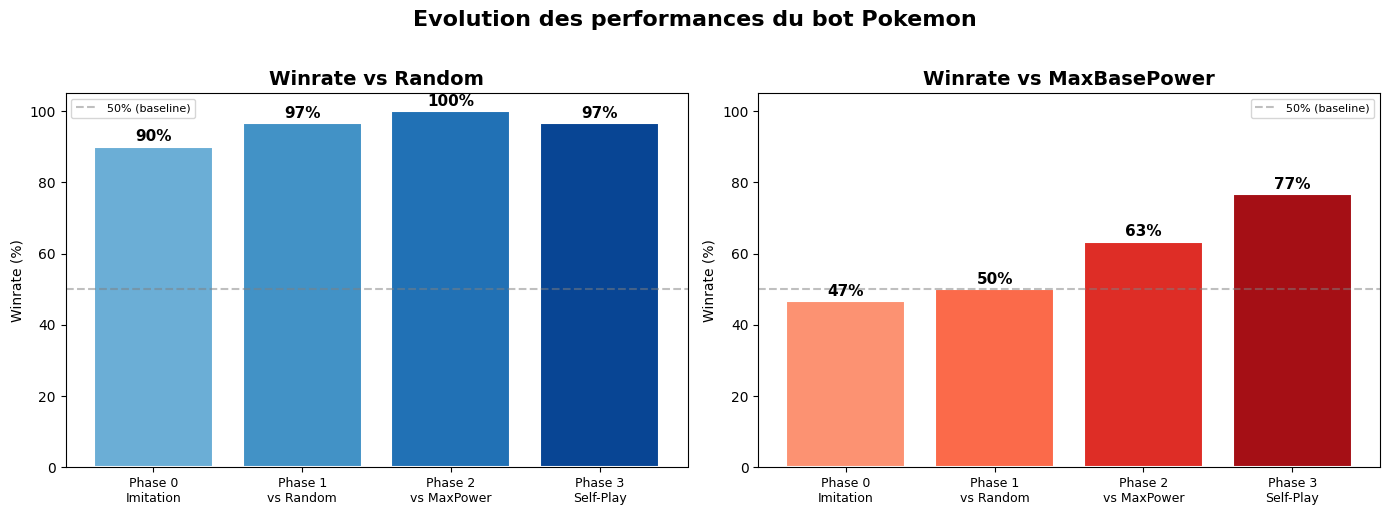


Graphique sauvegarde: evolution_performances.png


In [ ]:
# ============================================================
# Evaluation comparative + graphique d'evolution
# Pour chaque checkpoint sauvegarde (phases 0 a 3), on joue NUM_EVAL_BATTLES
# combats contre deux adversaires fixes (Random et MaxBasePower)
# et on compare les winrates pour mesurer la progression.
# ============================================================

mlflow_ensure_run()

import matplotlib.pyplot as plt
import os

CHECKPOINTS = [
    (str(MODEL_DIR / "model_imitation"), "Phase 0\nImitation"),
    (str(MODEL_DIR / "model_phase1"), "Phase 1\nvs Random"),
    (str(MODEL_DIR / "model_phase2"), "Phase 2\nvs MaxPower"),
    (str(MODEL_DIR / "model_final"), "Phase 3\nSelf-Play"),
]

# Nombre de combats par evaluation (augmenter pour plus de precision statistique)
NUM_EVAL_BATTLES = 30

def evaluate_model(model_path, opponent_strategy, n_battles):
    """Joue n_battles combats et retourne (winrate, avg_reward).
    deterministic=True : le modele joue son meilleur coup (pas d'exploration)."""
    loaded = MaskablePPO.load(model_path)
    poke_eval = PokemonEnv(battle_format="gen1randombattle", strict=False)
    env_eval = GymWrapper(poke_eval, opponent_strategy=opponent_strategy)
    env_eval = ActionMasker(env_eval, mask_fn)

    wins, total_reward = 0, 0.0
    for _ in range(n_battles):
        obs, _ = env_eval.reset()
        done, ep_reward = False, 0.0
        while not done:
            mask = env_eval.action_masks()
            action, _ = loaded.predict(obs, action_masks=mask, deterministic=True)
            obs, reward, terminated, truncated, info = env_eval.step(action)
            ep_reward += reward
            done = terminated or truncated
        battle = poke_eval.battle1
        if battle and battle.won:
            wins += 1
        total_reward += ep_reward

    env_eval.close()
    return wins / n_battles, total_reward / n_battles

# --- Evaluer chaque checkpoint ---

results_vs_random = []
results_vs_maxpower = []
labels = []

for model_path, label in CHECKPOINTS:
    if not os.path.exists(model_path + ".zip"):
        print(f"  {label}: checkpoint non trouve, skip")
        results_vs_random.append(0)
        results_vs_maxpower.append(0)
        labels.append(label)
        continue

    print(f"Evaluation de {label}...")
    wr_random, _ = evaluate_model(model_path, GymWrapper.OPPONENT_RANDOM, NUM_EVAL_BATTLES)
    wr_maxpow, avg_rew = evaluate_model(model_path, GymWrapper.OPPONENT_MAX_POWER, NUM_EVAL_BATTLES)
    results_vs_random.append(wr_random * 100)
    results_vs_maxpower.append(wr_maxpow * 100)
    labels.append(label)
    print(f"  vs Random:   {wr_random*100:.0f}% winrate")
    print(f"  vs MaxPower: {wr_maxpow*100:.0f}% winrate | reward moyen: {avg_rew:.1f}")

# --- Log metriques MLflow ---
phase_names = ["phase0_imitation", "phase1_vs_random", "phase2_vs_maxpower", "phase3_selfplay"]
for i in range(min(len(phase_names), len(results_vs_random), len(results_vs_maxpower))):
    mlflow.log_metric(f"eval_{phase_names[i]}_winrate_vs_random", results_vs_random[i])
    mlflow.log_metric(f"eval_{phase_names[i]}_winrate_vs_maxpower", results_vs_maxpower[i])

# --- Graphique ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(labels))
colors_random = ["#6baed6", "#4292c6", "#2171b5", "#084594"]
colors_maxpow = ["#fc9272", "#fb6a4a", "#de2d26", "#a50f15"]

# Winrate vs Random
bars1 = axes[0].bar(x, results_vs_random, color=colors_random, edgecolor="white", linewidth=1.5)
axes[0].set_title("Winrate vs Random", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Winrate (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylim(0, 105)
axes[0].axhline(y=50, color="gray", linestyle="--", alpha=0.5, label="50% (baseline)")
axes[0].legend(fontsize=8)
for bar, val in zip(bars1, results_vs_random):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f"{val:.0f}%", ha="center", fontsize=11, fontweight="bold")

# Winrate vs MaxBasePower
bars2 = axes[1].bar(x, results_vs_maxpower, color=colors_maxpow, edgecolor="white", linewidth=1.5)
axes[1].set_title("Winrate vs MaxBasePower", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Winrate (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=9)
axes[1].set_ylim(0, 105)
axes[1].axhline(y=50, color="gray", linestyle="--", alpha=0.5, label="50% (baseline)")
axes[1].legend(fontsize=8)
for bar, val in zip(bars2, results_vs_maxpower):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f"{val:.0f}%", ha="center", fontsize=11, fontweight="bold")

fig.suptitle("Evolution des performances du bot Pokemon", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "evolution_performances.png"), dpi=150, bbox_inches="tight")
plt.show()
mlflow.log_artifact(str(PROJECT_ROOT / "evolution_performances.png"), artifact_path="evaluation")
if mlflow.active_run():
    mlflow.end_run()
print("\nGraphique sauvegarde: evolution_performances.png")

## Démo finale — RL vs MaxBasePower (10 manches)

Lance 10 combats en direct entre le modèle final entraîné (`model_final`) et l'adversaire **MaxBasePower**.

> Ouvre **http://localhost:8000** dans ton navigateur pour regarder les combats en temps réel sur le serveur Showdown local.

In [ ]:
# ============================================================
# DEMO FINALE : 100 manches - Modele RL vs MaxBasePower
# Agent 1 = model_final (notre bot RL entraine en 3 phases)
# Agent 2 = MaxBasePower (l'adversaire heuristique de la Phase 2)
#
# DELAY_BETWEEN_TURNS : pause entre chaque tour pour pouvoir
# suivre le combat en direct sur http://localhost:8000
# Mettre a 0 pour une demo rapide sans visualisation.
# ============================================================

import time

# Charger le modele final (Phase 3 self-play)
model_demo = MaskablePPO.load(str(MODEL_DIR / "model_final"))

poke_env_demo = PokemonEnv(battle_format="gen1randombattle", strict=False)
env_demo = GymWrapper(
    poke_env_demo,
    opponent_strategy=GymWrapper.OPPONENT_MAX_POWER,
)
env_demo = ActionMasker(env_demo, mask_fn)

NUM_MANCHES = 100
DELAY_BETWEEN_TURNS = 1.5

rl_wins = 0
maxpow_wins = 0
match_results = []

print("=" * 56)
print("   DEMO FINALE : Modele RL  vs  MaxBasePower  (10 manches)")
print("   Regarde sur http://localhost:8000")
print("=" * 56)

for manche in range(1, NUM_MANCHES + 1):
    print(f"\n--- Manche {manche}/{NUM_MANCHES} ---")

    obs, _ = env_demo.reset()
    done = False
    turn = 0
    total_reward = 0.0

    while not done:
        mask = env_demo.action_masks()
        action, _ = model_demo.predict(obs, action_masks=mask, deterministic=True)
        obs, reward, terminated, truncated, info = env_demo.step(action)
        total_reward += reward
        done = terminated or truncated
        turn += 1
        time.sleep(DELAY_BETWEEN_TURNS)

    battle = poke_env_demo.battle1
    our_alive = sum(1 for m in battle.team.values() if not m.fainted) if battle else 0
    opp_alive = sum(1 for m in battle.opponent_team.values() if not m.fainted) if battle else 0

    if battle and battle.won:
        rl_wins += 1
        result = "RL GAGNE"
        match_results.append("RL")
    elif battle and battle.lost:
        maxpow_wins += 1
        result = "MaxPower GAGNE"
        match_results.append("MaxPower")
    else:
        result = "NUL"
        match_results.append("Nul")

    print(f"  {result} en {turn} tours")
    print(f"  Pokemon restants: RL={our_alive}/6, MaxPower={opp_alive}/6")
    print(f"  Reward cumule: {total_reward:.1f}")

env_demo.close()

# --- Recap ---
print("\n" + "=" * 56)
print("   RESULTATS FINAUX")
print("=" * 56)
for i, res in enumerate(match_results):
    icon = "W" if res == "RL" else ("L" if res == "MaxPower" else "D")
    print(f"   Manche {i+1}: {icon} ({res})")
print(f"\n   Score final: RL {rl_wins} - {maxpow_wins} MaxPower")
if rl_wins > maxpow_wins:
    print("   >>> Le modele RL remporte la serie ! <<<")
elif maxpow_wins > rl_wins:
    print("   >>> MaxBasePower remporte la serie. <<<")
else:
    print("   >>> Egalite. <<<")
print("=" * 56)

   DEMO FINALE : Modele RL  vs  MaxBasePower  (10 manches)
   Regarde sur http://localhost:8000

--- Manche 1/100 ---
  RL GAGNE en 28 tours
  Pokemon restants: RL=3/6, MaxPower=0/6
  Reward cumule: 73.8

--- Manche 2/100 ---
  RL GAGNE en 33 tours
  Pokemon restants: RL=2/6, MaxPower=0/6
  Reward cumule: 74.5

--- Manche 3/100 ---
  RL GAGNE en 36 tours
  Pokemon restants: RL=1/6, MaxPower=0/6
  Reward cumule: 53.5

--- Manche 4/100 ---
  RL GAGNE en 30 tours
  Pokemon restants: RL=1/6, MaxPower=0/6
  Reward cumule: 49.8

--- Manche 5/100 ---
  MaxPower GAGNE en 31 tours
  Pokemon restants: RL=0/6, MaxPower=1/6
  Reward cumule: -3.0

--- Manche 6/100 ---
  MaxPower GAGNE en 28 tours
  Pokemon restants: RL=0/6, MaxPower=1/6
  Reward cumule: -26.4

--- Manche 7/100 ---
  RL GAGNE en 31 tours
  Pokemon restants: RL=2/6, MaxPower=0/6
  Reward cumule: 66.3

--- Manche 8/100 ---
  RL GAGNE en 59 tours
  Pokemon restants: RL=2/6, MaxPower=0/6
  Reward cumule: 52.0

--- Manche 9/100 ---
  RL 

KeyboardInterrupt: 